In [ ]:
import torch

if torch.cuda.is_available():
    print("GPU is being used")
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("Only CPU is being used")

GPU is being used
GPU Name: Tesla T4


In [ ]:
# =====================================
# STEP 1 — SETUP
# =====================================

from google.colab import drive
drive.mount('/content/drive')

import torch
import random
import numpy as np

def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

print("Environment ready.")

Mounted at /content/drive
Environment ready.


In [ ]:
import torch
import random
import numpy as np

def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

print("Seed fixed.")

Seed fixed.


In [ ]:
import pandas as pd

base_path = "/content/drive/MyDrive/oral-cancer-project/data/processed"

train_df = pd.read_csv(f"{base_path}/train_split.csv")
val_df   = pd.read_csv(f"{base_path}/val_split.csv")
test_df  = pd.read_csv(f"{base_path}/test_split.csv")

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

Train: 1619
Val: 347
Test: 348


In [ ]:
print(train_df['image_path'].nunique(), len(train_df))
print(val_df['image_path'].nunique(), len(val_df))
print(test_df['image_path'].nunique(), len(test_df))

1619 1619
347 347
348 348


In [ ]:
from torch.utils.data import Dataset
from PIL import Image

class OralCancerBinaryDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.data = dataframe.reset_index(drop=True)
        self.transform = transform
        self.class_to_idx = {"cancer": 1, "non_cancer": 0}

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = self.data.loc[idx, "image_path"]
        label_name = self.data.loc[idx, "label"]
        label = self.class_to_idx[label_name]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

In [ ]:
from torchvision import transforms

train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(240, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.3,
        hue=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((240, 240)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [ ]:
from torch.utils.data import DataLoader

train_dataset = OralCancerBinaryDataset(train_df, train_transforms)
val_dataset   = OralCancerBinaryDataset(val_df, val_test_transforms)
test_dataset  = OralCancerBinaryDataset(test_df, val_test_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 1619
Val: 347
Test: 348


In [ ]:
!pip install timm --quiet

import timm
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# 🔥 EfficientNet-B1
model = timm.create_model('efficientnet_b1', pretrained=True, num_classes=2)
model = model.to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=25)

print("B1 model ready.")

Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/31.5M [00:00<?, ?B/s]

B1 model ready.


In [ ]:
from tqdm import tqdm
import torch

num_epochs = 25
best_val_acc = 0
patience = 5
counter = 0

scaler = torch.cuda.amp.GradScaler()

save_path = "/content/drive/MyDrive/oral-cancer-project/models/binary_efficientnet_b1.pth"

for epoch in range(num_epochs):

    # ================= TRAIN =================
    model.train()
    train_loss = 0
    train_correct = 0
    total = 0

    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}]")

    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, 1)
        train_correct += (preds == labels).sum().item()
        total += labels.size(0)

        loop.set_postfix(acc=train_correct/total, loss=train_loss/total)

    train_loss /= total
    train_acc = train_correct / total

    # ================= VALIDATION =================
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    scheduler.step()

    print(f"\nEpoch {epoch+1}:")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # ================= SAVE BEST =================
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), save_path)
        print("✅ Best model updated!")
        counter = 0
    else:
        counter += 1

    # ================= EARLY STOP =================
    if counter >= patience:
        print("⛔ Early stopping triggered.")
        break

print("Training complete.")
print("Best Validation Accuracy:", best_val_acc)

/tmp/ipykernel_3937/2290746214.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
Epoch [1/25]:   0%|          | 0/51 [00:00<?, ?it/s]/tmp/ipykernel_3937/2290746214.py:28: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch [1/25]:  59%|█████▉    | 30/51 [03:55<01:55,  5.49s/it, acc=0.673, loss=2.65]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch [1/25]: 100%|██████████| 51/51 [06:59<00:00,  8.23s/it, acc=0.701, loss=2.36]



Epoch 1:
Train Loss: 2.3641 | Train Acc: 0.7011
Val Loss: 3.7705 | Val Acc: 0.5591
✅ Best model updated!


Epoch [2/25]:  12%|█▏        | 6/51 [00:04<00:31,  1.42it/s, acc=0.854, loss=0.744]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch [2/25]: 100%|██████████| 51/51 [00:36<00:00,  1.39it/s, acc=0.83, loss=0.7]



Epoch 2:
Train Loss: 0.6996 | Train Acc: 0.8295
Val Loss: 0.5747 | Val Acc: 0.8156
✅ Best model updated!


Epoch [3/25]:  18%|█▊        | 9/51 [00:06<00:22,  1.91it/s, acc=0.885, loss=0.388]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch [3/25]:  71%|███████   | 36/51 [00:27<00:14,  1.01it/s, acc=0.885, loss=0.372]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch [3/25]: 100%|██████████| 51/51 [00:36<00:00,  1.39it/s, acc=0.889, loss=0.359]


...


Epoch 17:
Train Loss: 0.1377 | Train Acc: 0.9963
Val Loss: 0.2188 | Val Acc: 0.9568


Epoch [18/25]:  12%|█▏        | 6/51 [00:05<00:40,  1.12it/s, acc=1, loss=0.133]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch [18/25]:  57%|█████▋    | 29/51 [00:23<00:14,  1.47it/s, acc=0.996, loss=0.138]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch [18/25]: 100%|██████████| 51/51 [00:37<00:00,  1.36it/s, acc=0.996, loss=0.136]



Epoch 18:
Train Loss: 0.1363 | Train Acc: 0.9963
Val Loss: 0.2030 | Val Acc: 0.9625


Epoch [19/25]:   0%|          | 0/51 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch [19/25]:  84%|████████▍ | 43/51 [00:31<00:04,  1.76it/s, acc=0.996, loss=0.138]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch [19/25]: 100%|██████████| 51/51 [00:38<00:00,  1.34it/s, acc=0.996, loss=0.138]



Epoch 19:
Train Loss: 0.1381 | Train Acc: 0.9963
Val Loss: 0.2157 | Val Acc: 0.9625
⛔ Early stopping triggered.
Training complete.
Best Validation Accuracy: 0.9654178674351584


In [ ]:
model.load_state_dict(torch.load(save_path))
model.eval()

print("Best B1 model loaded.")

Best B1 model loaded.


In [ ]:
# ============================================
# CROSS-DATASET EVALUATION (B1)
# ============================================

import numpy as np
import torch
import torch.nn.functional as F
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

model.eval()

all_labels = []
all_preds = []
all_probs = []

# 🔥 Collect predictions
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = F.softmax(outputs, dim=1)

        _, preds = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs[:,1].cpu().numpy())

# Convert to numpy
all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)

# 🔥 IMPORTANT — source column from dataframe
test_sources = test_df['source'].values

print("========================================")
print(" OVERALL PERFORMANCE (B1)")
print("========================================")

print("\nConfusion Matrix:")
print(confusion_matrix(all_labels, all_preds))

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=["non_cancer","cancer"]))

print("ROC-AUC:", roc_auc_score(all_labels, all_probs))


# ============================================
# 🔬 PER-SOURCE ANALYSIS
# ============================================

print("\n========================================")
print(" CROSS-DATASET PERFORMANCE")
print("========================================")

unique_sources = np.unique(test_sources)

for src in unique_sources:
    print(f"\n🔍 SOURCE: {src}")

    idx = test_sources == src

    y_true = all_labels[idx]
    y_pred = all_preds[idx]
    y_prob = all_probs[idx]

    print("Samples:", len(y_true))

    cm = confusion_matrix(y_true, y_pred)
    print("\nConfusion Matrix:")
    print(cm)

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=["non_cancer","cancer"]))

    auc = roc_auc_score(y_true, y_prob)
    print("ROC-AUC:", auc)

    # 🔥 Extract false negatives
    fn = cm[1][0]
    print("❗ False Negatives:", fn)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


 OVERALL PERFORMANCE (B1)

Confusion Matrix:
[[157   0]
 [  4 187]]

Classification Report:
              precision    recall  f1-score   support

  non_cancer       0.98      1.00      0.99       157
      cancer       1.00      0.98      0.99       191

    accuracy                           0.99       348
   macro avg       0.99      0.99      0.99       348
weighted avg       0.99      0.99      0.99       348

ROC-AUC: 0.999199653183046

 CROSS-DATASET PERFORMANCE

🔍 SOURCE: Archive3
Samples: 192

Confusion Matrix:
[[ 82   0]
 [  3 107]]

Classification Report:
              precision    recall  f1-score   support

  non_cancer       0.96      1.00      0.98        82
      cancer       1.00      0.97      0.99       110

    accuracy                           0.98       192
   macro avg       0.98      0.99      0.98       192
weighted avg       0.98      0.98      0.98       192

ROC-AUC: 0.9988913525498891
❗ False Negatives: 3

🔍 SOURCE: OC_kaggle
Samples: 137

Confusion Matrix

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Classification Report:
              precision    recall  f1-score   support

  non_cancer       0.98      1.00      0.99       157
      cancer       1.00      0.98      0.99       191

    accuracy                           0.99       348
   macro avg       0.99      0.99      0.99       348
weighted avg       0.99      0.99      0.99       348

Confusion Matrix:
[[157   0]
 [  4 187]]
ROC-AUC Score: 0.999199653183046


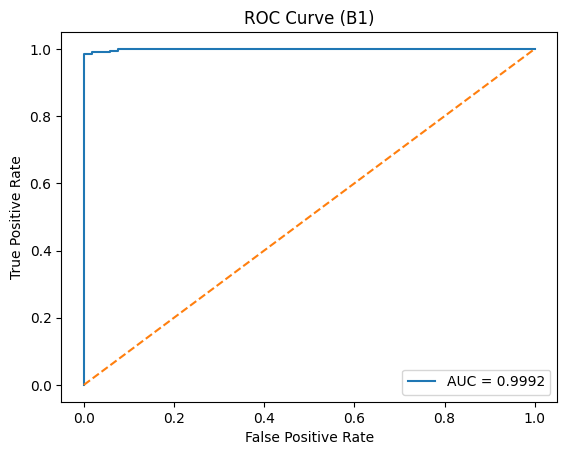

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import torch.nn.functional as F

all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = F.softmax(outputs, dim=1)

        _, preds = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs[:,1].cpu().numpy())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)

print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=["non_cancer","cancer"]))

cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:")
print(cm)

auc = roc_auc_score(all_labels, all_probs)
print("ROC-AUC Score:", auc)

# ROC Curve
fpr, tpr, _ = roc_curve(all_labels, all_probs)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (B1)")
plt.legend()
plt.show()